# Lab Experiment: Data Collection
## Web Scraping and APIs

**Course:** Data science  Laboratory
**Class:** B.Tech
**Duration:** 2 hours

---

### Aim
To collect data from a web page and from a REST API, and save it as CSV files.

### Objectives
1. Extract data from an HTML page using **BeautifulSoup**
2. Extract a table using **pandas.read_html**
3. Collect data from a **REST API** and parse the JSON response
4. Save all collected data to CSV files

### Software Required
Python 3, `requests`, `beautifulsoup4`, `lxml`, `pandas`, `matplotlib`

### Theory

There are two ways to collect data from the internet:

| | Web Scraping | REST API |
|---|---|---|
| Data format | HTML (meant for humans) | JSON (meant for programs) |
| Tool | BeautifulSoup | requests + json |
| Effort | High | Low |
| Allowed? | Only if the site permits it | Yes, that is what it is for |

**Rule: if an API exists, use the API.** Scrape only when there is no API.

---
## Step 0: Setup

In [1]:
# Install if needed (uncomment the line below)
# !pip install requests beautifulsoup4 lxml pandas matplotlib

import io
import json
import requests
import pandas as pd
import numpy as np
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
from pathlib import Path

# Folder to store collected data
DATA = Path("data")
DATA.mkdir(exist_ok=True)

print("Setup complete. Data will be saved in:", DATA.resolve())

Setup complete. Data will be saved in: D:\SEM3\DS\Ass\Lab-1\Lab-1\data


---
## Step 1: Rules Before Collecting Data

Before scraping any website, check these four things:

1. **Check `robots.txt`** — visit `https://website.com/robots.txt`. It says which pages
   crawlers may visit.
2. **Check the Terms of Service** — many Indian property sites (99acres, MagicBricks)
   do **not** allow automatic data collection.
3. **Go slow** — wait 1–2 seconds between requests. Do not send requests in a fast loop.
4. **Never collect personal data** — no names, phone numbers or email IDs.

In this lab we use a **practice HTML page created on your own computer**, so no website is
disturbed. The API we use (Open-Meteo) is free and openly allows this.

In [2]:
# Check if a website allows scraping
from urllib.robotparser import RobotFileParser

def can_scrape(url):
    rp = RobotFileParser()
    rp.set_url(url.split("/")[0] + "//" + url.split("/")[2] + "/robots.txt")
    try:
        rp.read()
        return rp.can_fetch("*", url)
    except Exception:
        return "could not check (no internet)"

print("Wikipedia :", can_scrape("https://en.wikipedia.org/wiki/Bangalore"))
print("99acres   :", can_scrape("https://www.99acres.com/property-in-bangalore-ffid"))

Wikipedia : False
99acres   : False


---
# EXPERIMENT 1
## Collecting Data from an HTML Page

We will collect Bengaluru house listings from a web page.

**How scraping works:**

```
HTML page  →  BeautifulSoup  →  find the tags  →  get the text  →  DataFrame  →  CSV
```

[![Chat-GPT-Image-Aug-13-2026-06-43-45-PM.png](https://i.postimg.cc/NjJc6QCL/Chat-GPT-Image-Aug-13-2026-06-43-45-PM.png)](https://postimg.cc/JskvmCLW)

In [3]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

# 1. Online website
url = "https://quotes.toscrape.com/"

# 2. Read the web page
response = requests.get(url)

# 3. Parse HTML
soup = BeautifulSoup(response.text, "html.parser")

# 4. Find the required tags
quotes = soup.find_all("div", class_="quote")

# 5. Extract the text
data = []

for quote in quotes:
    text = quote.find("span", class_="text").get_text(strip=True)
    author = quote.find("small", class_="author").get_text(strip=True)

    data.append({
        "Quote": text,
        "Author": author
    })

# 6. Create DataFrame
df = pd.DataFrame(data)

print(df)

# 7. Save to CSV
df.to_csv("quotes.csv", index=False)

print("Data saved to quotes.csv")

                                               Quote             Author
0  “The world as we have created it is a process ...    Albert Einstein
1  “It is our choices, Harry, that show what we t...       J.K. Rowling
2  “There are only two ways to live your life. On...    Albert Einstein
3  “The person, be it gentleman or lady, who has ...        Jane Austen
4  “Imperfection is beauty, madness is genius and...     Marilyn Monroe
5  “Try not to become a man of success. Rather be...    Albert Einstein
6  “It is better to be hated for what you are tha...         André Gide
7  “I have not failed. I've just found 10,000 way...   Thomas A. Edison
8  “A woman is like a tea bag; you never know how...  Eleanor Roosevelt
9  “A day without sunshine is like, you know, nig...       Steve Martin
Data saved to quotes.csv


In [4]:
import json
import re
import pandas as pd
 
INPUT_FILE = "data/House.html"
OUTPUT_FILE = "bengaluru_houses.csv"
 
 
# ---------- STEP 1: read the file ----------
html = open(INPUT_FILE, encoding="utf-8").read()
print("File read. Size:", len(html), "characters")
 
 
# ---------- STEP 2: cut out the JSON ----------
marker = "window.__initialData__="
start = html.find(marker) + len(marker)
 

File read. Size: 1774012 characters


##### Find where the marker ends; that's where the embedded data starts

In [2]:

 
# Read forward until the opening { is closed by its matching }
depth = 0
for end in range(start, len(html)):
    if html[end] == "{":
        depth += 1
    elif html[end] == "{":
        depth -= 1
        if depth == 0:
            break
 

##### depth acts like a brace counter. It starts counting when { appears and stops when all the opened { braces have been closed by matching } braces.

In [5]:
import json
import pandas as pd

# File paths
INPUT_FILE = "data/House.html"
OUTPUT_FILE = "bengaluru_houses.csv"

# ---------- STEP 1: Read the HTML file ----------
html = open(INPUT_FILE, encoding="utf-8").read()

print("File read successfully.")
print("File size:", len(html), "characters")


# ---------- STEP 2: Find the embedded JSON ----------
marker = "window.__initialData__="

start = html.find(marker)

if start == -1:
    raise ValueError("JSON marker was not found in the HTML file.")

start = start + len(marker)

# Skip any spaces before the JSON object
while start < len(html) and html[start].isspace():
    start += 1

print("JSON starts at position:", start)


# ---------- STEP 3: Find the end of the JSON object ----------
depth = 0
end = None

for i in range(start, len(html)):

    if html[i] == "{":
        depth += 1

    elif html[i] == "}":
        depth -= 1

        if depth == 0:
            end = i
            break

if end is None:
    raise ValueError("Could not find the end of the JSON object.")

print("JSON ends at position:", end)


# ---------- STEP 4: Convert JSON text into Python dictionary ----------
json_text = html[start:end + 1]

data = json.loads(json_text)

print("JSON loaded successfully.")


# ---------- STEP 5: Reach the list of properties ----------
properties = data["srp"]["pageData"]["properties"]

print("Number of listings found:", len(properties))


# ---------- STEP 6: Helper functions ----------

def price_in_lakh(rupees):
    """
    Convert rupees into lakh.
    Example:
    21998600 -> 219.99 lakh
    """
    try:
        return round(float(rupees) / 100000, 2)

    except (TypeError, ValueError):
        return None


def to_number(value):
    """
    Convert a value to number.
    Example:
    '2600' -> 2600.0
    None -> None
    """
    try:
        return float(value)

    except (TypeError, ValueError):
        return None


# ---------- STEP 7: Extract required property fields ----------

rows = []

for p in properties:

    rows.append({
        "location": p.get("LOCALITY"),

        "bhk": to_number(
            p.get("BEDROOM_NUM")
        ),

        "sqft": to_number(
            p.get("LOCALIZED_AREA_VALUE")
        ),

        "area_unit": p.get(
            "LOCALIZED_AREA_UNIT_LABEL"
        ),

        "price_lakh": price_in_lakh(
            p.get("MIN_PRICE")
        ),

        "price_text": p.get(
            "PRICE"
        ),

        "price_per_sqft": to_number(
            p.get("PRICE_SQFT")
        ),

        "property_name": p.get(
            "PROP_NAME"
        )
    })


# ---------- STEP 8: Create DataFrame ----------

houses = pd.DataFrame(rows)

print("\nDataFrame created successfully.")


# We deliberately do NOT collect:
# - Agent names
# - Phone numbers
# - Email IDs
#
# because these are personal information.


# ---------- STEP 9: Quick check ----------

print(
    "\nAll areas in sqft?",
    (houses["area_unit"] == "sqft").all()
)

print("\nMissing values:")
print(
    houses.isna().sum().to_string()
)


# ---------- STEP 10: Save to CSV ----------

houses.to_csv(
    OUTPUT_FILE,
    index=False
)

print(
    "\nSaved",
    len(houses),
    "rows to",
    OUTPUT_FILE
)


# ---------- STEP 11: Display first 10 records ----------

print("\nFirst 10 records:")

print(
    houses.head(10).to_string(index=False)
)

File read successfully.
File size: 1774012 characters
JSON starts at position: 1131731
JSON ends at position: 1758534
JSON loaded successfully.
Number of listings found: 27

DataFrame created successfully.

All areas in sqft? True

Missing values:
location          0
bhk               0
sqft              0
area_unit         0
price_lakh        0
price_text        0
price_per_sqft    0
property_name     0

Saved 27 rows to bengaluru_houses.csv

First 10 records:
                        location  bhk   sqft area_unit  price_lakh      price_text  price_per_sqft              property_name
          Bommasandra, Bangalore  5.0 2600.0      sqft      219.99          2.2 Cr          8461.0                SKR Gardens
5th Block Hbr Layout, HBR Layout 12.0 1200.0      sqft      380.00          3.8 Cr         31666.0                           
        Sarjapur Road, Bangalore  4.0 3040.0      sqft      225.00 2.25  - 3.28 Cr          9087.0 CasaLife by Bhavisha Homes
           Whitefield, Bangalo

##### Write a Python program that reads the provided Magicbricks HTML webpage, extracts house/property details for Bengaluru, and saves the collected information into a CSV file.

### Result — Experiment 1

**Number of listings collected:** __27____

**Columns collected:** ___location, bhk, sqft, area_unit, price_lakh, price_text, price_per_sqft, property_name___

**File saved:** __bengaluru_houses.csv____

**Observation:** The provided Magicbricks HTML webpage was read using Python, and the required Bengaluru property details were extracted and stored in a Pandas DataFrame. The collected data was successfully saved as bengaluru_houses.csv. Personal information such as agent names and phone numbers was not collected.

> ...

---
# EXPERIMENT 2
## Collecting Data from a REST API (Weather)

We will collect Bengaluru weather data from the **Open-Meteo API**.
It is free and needs **no API key**.

**How an API call works:**

```
https://api.open-meteo.com/v1/forecast ? latitude=12.97 & longitude=77.59 & hourly=temperature_2m
|________ address of the API _________|  |____________ what we are asking for ____________|
```

The API replies with **JSON**, which Python reads as a dictionary.

**Important status codes:**

| Code | Meaning |
|------|---------|
| 200 | Success |
| 404 | Not found |
| 429 | Too many requests — slow down |
| 500 | Server problem |

[![44.png](https://i.postimg.cc/05hNftLY/44.png)](https://postimg.cc/K4rFc5cj)

In [6]:
# --- Step 2a: Ask the API for the current weather ---

URL = "https://api.open-meteo.com/v1/forecast"

params = {
    "latitude": 12.9716,        # Bengaluru
    "longitude": 77.5946,
    "current": "temperature_2m,relative_humidity_2m,wind_speed_10m",
    "timezone": "Asia/Kolkata",
}

try:
    response = requests.get(URL, params=params, timeout=20)
    print("Status code:", response.status_code)
    weather = response.json()
except Exception as e:
    weather = None
    print("No internet:", e)

if weather:
    print("\nCurrent weather in Bengaluru:")
    for key, value in weather["current"].items():
        print(f"  {key:22s}: {value}")

Status code: 200

Current weather in Bengaluru:
  time                  : 2026-08-18T18:45
  interval              : 900
  temperature_2m        : 24.2
  relative_humidity_2m  : 74
  wind_speed_10m        : 11.9


In [7]:
# --- Step 2b: Collect hourly temperature for the next 7 days ---

params2 = {
    "latitude": 12.9716,
    "longitude": 77.5946,
    "hourly": "temperature_2m,relative_humidity_2m,precipitation",
    "timezone": "Asia/Kolkata",
    "forecast_days": 7,
}

try:
    r = requests.get(URL, params=params2, timeout=20)
    result = r.json()
    wx = pd.DataFrame(result["hourly"])       # JSON -> DataFrame
    wx["time"] = pd.to_datetime(wx["time"])
    print("Collected", len(wx), "hourly records")
except Exception as e:
    wx = pd.DataFrame()
    print("No internet — the next cell will create sample data.")

wx.head()

Collected 168 hourly records


,time,temperature_2m,relative_humidity_2m,precipitation
0,2026-08-18 00:00:00,21.4,86,0.1
1,2026-08-18 01:00:00,21.0,87,0.2
2,2026-08-18 02:00:00,20.7,89,0.1
3,2026-08-18 03:00:00,20.2,89,0.0
4,2026-08-18 04:00:00,19.9,90,0.0


### Exercise 2

1. Change the latitude and longitude to **Mysuru (12.2958, 76.6394)** and collect its
   weather. Save it as `weather_mysuru.csv`.
2. Add `"wind_speed_10m"` to the `hourly` parameter and collect it too.
3. Set `"latitude": "abcd"` and run the cell. What status code do you get?
4. Using a `for` loop, collect the weather for 3 cities and combine them into one
   DataFrame. Remember to add `time.sleep(1)` inside the loop. Why is the sleep needed?

In [12]:
# Write your Exercise 2 answers here

# 1.
latitude = 12.2958
longitude = 76.6394

url = "https://api.open-meteo.com/v1/forecast"
params = {
    "latitude": 12.2958,
    "longitude": 76.6394,
    "hourly": "temperature_2m,relative_humidity_2m",
    "past_days": 7
}
df.to_csv("weather_mysuru.csv", index=False)

import requests
import pandas as pd
import time

# ============================================================
# EXERCISE 2
# ============================================================

url = "https://api.open-meteo.com/v1/forecast"


# ------------------------------------------------------------
# 1. Collect weather data for Mysuru
# ------------------------------------------------------------

latitude = 12.2958
longitude = 76.6394

params = {
    "latitude": latitude,
    "longitude": longitude,
    "hourly": "temperature_2m,relative_humidity_2m",
    "past_days": 7
}

response = requests.get(url, params=params)

print("Mysuru status code:", response.status_code)

data = response.json()

df_mysuru = pd.DataFrame({
    "time": data["hourly"]["time"],
    "temperature_2m": data["hourly"]["temperature_2m"],
    "relative_humidity_2m": data["hourly"]["relative_humidity_2m"]
})

df_mysuru.to_csv("weather_mysuru.csv", index=False)

print("Mysuru weather saved to weather_mysuru.csv")
print("Number of Mysuru records:", len(df_mysuru))

print("\nFirst 5 records:")
print(df_mysuru.head())


# ------------------------------------------------------------
# 2. Add wind_speed_10m
# ------------------------------------------------------------

params = {
    "latitude": 12.2958,
    "longitude": 76.6394,
    "hourly": "temperature_2m,relative_humidity_2m,wind_speed_10m",
    "past_days": 7
}

response = requests.get(url, params=params)

print("\nWind speed status code:", response.status_code)

data = response.json()

df_wind = pd.DataFrame({
    "time": data["hourly"]["time"],
    "temperature_2m": data["hourly"]["temperature_2m"],
    "relative_humidity_2m": data["hourly"]["relative_humidity_2m"],
    "wind_speed_10m": data["hourly"]["wind_speed_10m"]
})

print("\nColumns after adding wind speed:")
print(df_wind.columns.tolist())

print("\nFirst 5 records:")
print(df_wind.head())


# ------------------------------------------------------------
# 3. Test invalid latitude
# ------------------------------------------------------------

params_invalid = {
    "latitude": "abcd",
    "longitude": 76.6394,
    "hourly": "temperature_2m",
    "past_days": 7
}

response_invalid = requests.get(
    url,
    params=params_invalid
)

print("\nInvalid latitude status code:",
      response_invalid.status_code)


# ------------------------------------------------------------
# 4. Collect weather for 3 cities using a for loop
# ------------------------------------------------------------

cities = {
    "Bengaluru": (12.9716, 77.5946),
    "Mysuru": (12.2958, 76.6394),
    "Chennai": (13.0827, 80.2707)
}

all_data = []

for city, coordinates in cities.items():

    latitude = coordinates[0]
    longitude = coordinates[1]

    params = {
        "latitude": latitude,
        "longitude": longitude,
        "hourly": "temperature_2m,relative_humidity_2m,wind_speed_10m",
        "past_days": 7
    }

    response = requests.get(url, params=params)

    print(city, "status code:", response.status_code)

    data = response.json()

    city_df = pd.DataFrame({
        "time": data["hourly"]["time"],
        "temperature_2m": data["hourly"]["temperature_2m"],
        "relative_humidity_2m": data["hourly"]["relative_humidity_2m"],
        "wind_speed_10m": data["hourly"]["wind_speed_10m"]
    })

    city_df["city"] = city

    all_data.append(city_df)

    # Wait for 1 second before the next API request
    time.sleep(1)


# Combine all three cities
three_city_df = pd.concat(
    all_data,
    ignore_index=True
)

print("\nCombined 3-city DataFrame:")
print(three_city_df.head())

print("\nTotal records:", len(three_city_df))

# Save combined data
three_city_df.to_csv(
    "weather_3_cities.csv",
    index=False
)

print("\nData saved to weather_3_cities.csv")

Mysuru status code: 200
Mysuru weather saved to weather_mysuru.csv
Number of Mysuru records: 336

First 5 records:
               time  temperature_2m  relative_humidity_2m
0  2026-08-11T00:00            21.1                    97
1  2026-08-11T01:00            21.3                    96
2  2026-08-11T02:00            22.6                    90
3  2026-08-11T03:00            24.2                    81
4  2026-08-11T04:00            25.8                    73

Wind speed status code: 200

Columns after adding wind speed:
['time', 'temperature_2m', 'relative_humidity_2m', 'wind_speed_10m']

First 5 records:
               time  temperature_2m  relative_humidity_2m  wind_speed_10m
0  2026-08-11T00:00            21.1                    97             8.7
1  2026-08-11T01:00            21.3                    96             8.6
2  2026-08-11T02:00            22.6                    90            10.8
3  2026-08-11T03:00            24.2                    81            12.5
4  2026-08-11T04:

### Result — Experiment 2

**API used:** ____Open-Meteo Weather API__

**Number of records collected:** __336____

**Columns collected:** __time, temperature_2m, relative_humidity_2m, wind_speed_10m____

**File saved:** __weather_mysuru.csv____

**Observation:** Weather data for Mysuru was successfully collected using the Open-Meteo Weather API with latitude 12.2958 and longitude 76.6394. A total of 336 hourly records were collected, including temperature, relative humidity, and wind speed. The data was saved as weather_mysuru.csv. An invalid latitude produced a 400 status code. Weather data for Bengaluru, Mysuru, and Chennai was also collected using a for loop and combined into a DataFrame containing 1008 records. A 1-second delay was used between API requests.

> ...

---
# EXPERIMENT 3
## Collecting Air Quality Data from an API

Same method as Experiment 2, but a different API.
This data can later be used for **air quality (AQI) prediction**.

[![34.png](https://i.postimg.cc/QCKdD5Wc/34.png)](https://postimg.cc/kR9mF2s5)

In [13]:
# --- Collect air pollution data for Bengaluru ---

AQ_URL = "https://air-quality-api.open-meteo.com/v1/air-quality"

params3 = {
    "latitude": 12.9716,
    "longitude": 77.5946,
    "hourly": "pm2_5,pm10,nitrogen_dioxide,ozone",
    "timezone": "Asia/Kolkata",
    "past_days": 7,
}

try:
    r = requests.get(AQ_URL, params=params3, timeout=20)
    print("Status code:", r.status_code)
    aq = pd.DataFrame(r.json()["hourly"])
    aq["time"] = pd.to_datetime(aq["time"])
except Exception as e:
    print("No internet — creating sample data")
    

aq.to_csv(DATA / "air_quality.csv", index=False)
print("Saved to", DATA / "air_quality.csv")
print("Shape:", aq.shape)

aq.head()

Status code: 200
Saved to data\air_quality.csv
Shape: (288, 5)


,time,pm2_5,pm10,nitrogen_dioxide,ozone
0,2026-08-11 00:00:00,8.4,10.7,17.8,26.0
1,2026-08-11 01:00:00,7.2,9.2,14.8,26.0
2,2026-08-11 02:00:00,6.2,8.0,12.4,26.0
3,2026-08-11 03:00:00,5.6,7.5,10.8,26.0
4,2026-08-11 04:00:00,5.4,7.6,9.9,26.0


Average PM2.5: 7.4 ug/m3
Highest PM2.5: 16.0 ug/m3

Missing values in each column:
time                0
pm2_5               0
pm10                0
nitrogen_dioxide    0
ozone               0
dtype: int64


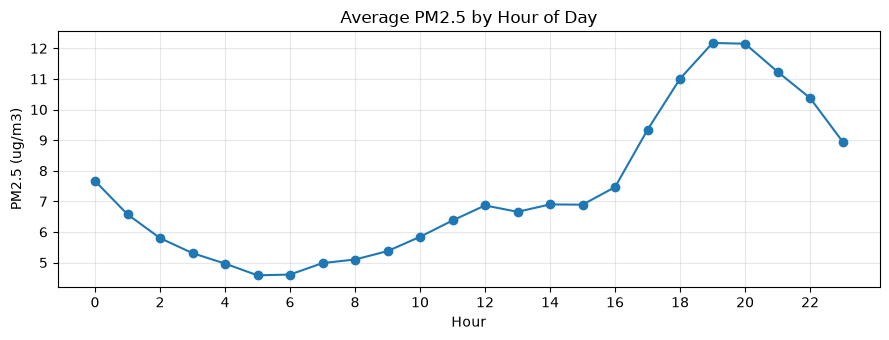

In [14]:
# --- Check what we collected ---

print("Average PM2.5:", round(aq["pm2_5"].mean(), 1), "ug/m3")
print("Highest PM2.5:", round(aq["pm2_5"].max(), 1), "ug/m3")
print("\nMissing values in each column:")
print(aq.isna().sum())

# Average PM2.5 for each hour of the day
by_hour = aq.groupby(aq["time"].dt.hour)["pm2_5"].mean()

plt.figure(figsize=(9, 3.5))
plt.plot(by_hour.index, by_hour.values, marker="o")
plt.title("Average PM2.5 by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("PM2.5 (ug/m3)")
plt.xticks(range(0, 24, 2))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Exercise 3

1. Collect the air quality data for **Delhi (28.6139, 77.2090)** and compare the average
   PM2.5 with Bengaluru's. Which city is more polluted?
2. Increase `past_days` from 7 to 30. How many rows do you get now?
3. Add `"sulphur_dioxide"` and `"carbon_monoxide"` to the list of pollutants.

In [15]:
# Write your Exercise 3 answers here
import requests
import pandas as pd

# Open-Meteo Air Quality API
url = "https://air-quality-api.open-meteo.com/v1/air-quality"


# ============================================================
# 1. Delhi air quality and comparison with Bengaluru
# ============================================================

# Bengaluru
bengaluru_params = {
    "latitude": 12.9716,
    "longitude": 77.5946,
    "hourly": "pm10,pm2_5,carbon_monoxide",
    "past_days": 7
}

response_bengaluru = requests.get(url, params=bengaluru_params)
data_bengaluru = response_bengaluru.json()

bengaluru_df = pd.DataFrame({
    "time": data_bengaluru["hourly"]["time"],
    "pm10": data_bengaluru["hourly"]["pm10"],
    "pm2_5": data_bengaluru["hourly"]["pm2_5"],
    "carbon_monoxide": data_bengaluru["hourly"]["carbon_monoxide"]
})

bengaluru_avg = bengaluru_df["pm2_5"].mean()

print("Bengaluru average PM2.5:", bengaluru_avg)


# Delhi
delhi_params = {
    "latitude": 28.6139,
    "longitude": 77.2090,
    "hourly": "pm10,pm2_5,carbon_monoxide",
    "past_days": 7
}

response_delhi = requests.get(url, params=delhi_params)
data_delhi = response_delhi.json()

delhi_df = pd.DataFrame({
    "time": data_delhi["hourly"]["time"],
    "pm10": data_delhi["hourly"]["pm10"],
    "pm2_5": data_delhi["hourly"]["pm2_5"],
    "carbon_monoxide": data_delhi["hourly"]["carbon_monoxide"]
})

delhi_avg = delhi_df["pm2_5"].mean()

print("Delhi average PM2.5:", delhi_avg)


# Compare the two cities
if delhi_avg > bengaluru_avg:
    print("Delhi is more polluted based on average PM2.5.")
else:
    print("Bengaluru is more polluted based on average PM2.5.")


# ============================================================
# 2. Increase past_days from 7 to 30
# ============================================================

delhi_30_params = {
    "latitude": 28.6139,
    "longitude": 77.2090,
    "hourly": "pm10,pm2_5,carbon_monoxide",
    "past_days": 30
}

response_30 = requests.get(url, params=delhi_30_params)
data_30 = response_30.json()

delhi_30_df = pd.DataFrame({
    "time": data_30["hourly"]["time"],
    "pm10": data_30["hourly"]["pm10"],
    "pm2_5": data_30["hourly"]["pm2_5"],
    "carbon_monoxide": data_30["hourly"]["carbon_monoxide"]
})

print("Number of records for 30 days:", len(delhi_30_df))


# ============================================================
# 3. Add sulphur_dioxide and carbon_monoxide
# ============================================================

delhi_extra_params = {
    "latitude": 28.6139,
    "longitude": 77.2090,
    "hourly": "pm10,pm2_5,carbon_monoxide,sulphur_dioxide",
    "past_days": 7
}

response_extra = requests.get(url, params=delhi_extra_params)
data_extra = response_extra.json()

delhi_extra_df = pd.DataFrame({
    "time": data_extra["hourly"]["time"],
    "pm10": data_extra["hourly"]["pm10"],
    "pm2_5": data_extra["hourly"]["pm2_5"],
    "carbon_monoxide": data_extra["hourly"]["carbon_monoxide"],
    "sulphur_dioxide": data_extra["hourly"]["sulphur_dioxide"]
})

print("\nPollutants collected:")
print(delhi_extra_df.columns.tolist())

print("\nNumber of records:", len(delhi_extra_df))

Bengaluru average PM2.5: 7.342013888888889
Delhi average PM2.5: 63.49583333333333
Delhi is more polluted based on average PM2.5.
Number of records for 30 days: 840

Pollutants collected:
['time', 'pm10', 'pm2_5', 'carbon_monoxide', 'sulphur_dioxide']

Number of records: 288


### Result — Experiment 3

**API used:** ___Open-Meteo Air Quality API___

**Pollutants collected:** __['time', 'pm10', 'pm2_5', 'carbon_monoxide', 'sulphur_dioxide']____

**Number of records:** ___840___

**Observation:**
Air quality data was collected using the Open-Meteo Air Quality API. PM10, PM2.5, and carbon monoxide (CO) were collected as hourly pollutant data. The average PM2.5 values of Delhi and Bengaluru were compared to determine the more polluted city. The data collection period was increased from 7 days to 30 days, and additional pollutants including sulphur dioxide were also collected.
> ...

# Creating a Large Air Quality & Weather Dataset

## Objective

Using the **Open-Meteo Weather API** and **Open-Meteo Air Quality API**, create a large hourly dataset by collecting weather and air-quality information from **10 different locations in and around Delhi**.

### 📌 Dataset Requirements

- **Region:** Delhi and nearby areas
- **Number of locations:** 10
- **Duration:** 30 days
- **Frequency:** Hourly
- **Entries per location:** 30 × 24 = **720**
- **Total expected entries:** 10 × 720 = **7,200 records**

### 📍 Suggested Locations

1. Connaught Place
2. Rohini
3. Dwarka
4. Saket
5. Lajpat Nagar
6. Karol Bagh
7. Anand Vihar
8. Vasant Kunj
9. Noida
10. Delhi Airport

### 🌦️ Weather Variables

Collect the following weather information:

- Temperature
- Relative humidity
- Precipitation
- Wind speed

### 🌫️ Air Quality Variables

Collect the following air-pollution information:

- PM2.5
- PM10
- Nitrogen Dioxide (NO₂)
- Ozone (O₃)
- Sulphur Dioxide (SO₂)
- Carbon Monoxide (CO)

### 📊 Expected Dataset Structure

The final dataset should contain columns such as:

`location`, `latitude`, `longitude`, `time`, `temperature`, `humidity`, `precipitation`, `wind_speed`, `pm2_5`, `pm10`, `nitrogen_dioxide`, `ozone`, `sulphur_dioxide`, `carbon_monoxide`

### 🧹 Data Processing Tasks

1. Collect data from the APIs for all 10 locations.
2. Convert the API responses into Pandas DataFrames.
3. Add the location name, latitude, and longitude.
4. Combine all locations into one dataset.
5. Check for missing or invalid values.
6. Handle missing values appropriately.
7. Save the final dataset as a CSV file.

### 🔍 Analysis Question

After creating the dataset, answer the following:

> **Which location in and around Delhi has the highest average PM2.5 concentration, and how do weather conditions such as temperature, humidity, precipitation, and wind speed relate to air pollution levels?**

### 📈 Dataset Size

**10 Locations × 30 Days × 24 Hours = 7,200 hourly records**

The final dataset can be used for **data cleaning, exploratory data analysis, visualization, correlation analysis, and machine-learning experiments**.

In [16]:
# --- Final check: list all the files we collected ---

print("Files collected in this lab:\n")
for f in sorted(DATA.glob("*")):
    print(f"  {f.name:22s}  {f.stat().st_size:>8,} bytes")

Files collected in this lab:

  air_quality.csv           11,187 bytes
  House.html              1,774,801 bytes
  Magicbrick.html         1,502,328 bytes
  Magicbrick_files          81,920 bytes
  weather.csv                5,600 bytes


---
## Viva Questions

1. What is web scraping?
2. What is the difference between web scraping and using an API?
3. What is `robots.txt` and why should you check it?
4. What does BeautifulSoup do?
5. What is the difference between `find()` and `find_all()`?
6. What is JSON? How is it related to a Python dictionary?
7. What does status code 200 mean? What does 404 mean?
8. What is a query parameter in an API call?
9. Why should you wait a few seconds between requests?
10. Why is using an API better than scraping the same website?
11. What does `pd.read_html()` do?
12. Why do we save the collected data as a CSV file?

## Conclusion

> Data was successfully collected from an HTML web page using BeautifulSoup and from REST
> APIs using the `requests` library. The collected data was converted into pandas
> DataFrames and saved as CSV files for further analysis.

